<a href="https://colab.research.google.com/github/leeseul0919/AR_Navigation_Assets/blob/main/%ED%9A%8C%EA%B7%80%EB%AA%A8%EB%8D%B8_%ED%85%8C%EC%8A%A4%ED%8A%B8_%EC%A0%95%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

먼저 DB port_event_voyage 테이블에서 vesselid, destcode, ata, atb, waiting_minutes을 조회해서 csv파일로 다운받음

(waiting_minutes는 EXTRACT(EPOCH FROM age(atb, ata)) / 60) => 분 단위)


#데이터 전처리

In [ ]:
#파일 불러오기
import datetime
import csv

class voyage_record_data:
    def __init__(self, a, b, c, d):
        self.destcode = c
        self.ata = datetime.datetime.strptime(a, "%Y-%m-%d %H:%M:%S+09")
        self.atb = datetime.datetime.strptime(b, "%Y-%m-%d %H:%M:%S+09")
        self.record_count = 0
        self.duration = d

all_lst = []

# CSV 파일 열기
with open('all_train_data_2.csv', 'r') as f:
    rdr = csv.reader(f)
    next(rdr)
    # 각 행을 읽어서 리스트에 추가
    for line in rdr:
        ata_str = line[2]
        atb_str = line[3]
        duration = line[4]
        destcode = line[1]

        # voyage_record_data 객체 생성 및 리스트에 추가
        data = voyage_record_data(ata_str, atb_str, destcode, duration)
        all_lst.append(data)

print(f"Number of data points: {len(all_lst)}")

# 확인을 위해 첫 번째 데이터 포인트 출력
if all_lst:
    print(f"First data point: ATA={all_lst[0].ata}, ATB={all_lst[0].atb}, Duration={all_lst[0].duration}, Destcode={all_lst[0].destcode}")

Number of data points: 518901
First data point: ATA=2023-11-25 08:30:00, ATB=2023-12-28 12:21:03, Duration=47751.05, Destcode=SGSIN


#데이터 전처리 - 항구 코드 별로 분류

In [ ]:
destcode_dict = {}
for item in all_lst:
    if item.destcode not in destcode_dict:
        destcode_dict[item.destcode] = []
    destcode_dict[item.destcode].append(item)
dict_len = len(destcode_dict)
print(dict_len)

1719


#데이터 작업 - 선박 수 카운트 알고리즘

In [ ]:
# 결과를 저장할 리스트
result_lst = []
complete_port = 0
for k in destcode_dict.keys():
    all_lst = destcode_dict[k]
    all_lst.sort(key=lambda x: x.ata) #ata 순으로 정렬
    temp_lst = []
    start_check_time = datetime.datetime.strptime("2023-11-25 00:00:00", "%Y-%m-%d %H:%M:%S") #체크 시작하는 날짜
    end_check_time = datetime.datetime.strptime("2024-07-21 00:00:00", "%Y-%m-%d %H:%M:%S") #체크 끝나는 날짜

    while start_check_time <= end_check_time:
        num_lst = []
        for i in range(len(temp_lst)):
            item = temp_lst[i]
            if item.atb < start_check_time:
                num_lst.append(i)
                result_lst.append(item)

        # 역순으로 삭제
        for n in sorted(num_lst, reverse=True):
            temp_lst.pop(n)
        num_lst.clear()

        num_lst = []
        for i in range(len(all_lst)):
            item = all_lst[i]
            if start_check_time <= item.ata < (start_check_time + datetime.timedelta(hours=1)):
                num_lst.append(i)
                temp_lst.append(item)
            else:
                break

        # 역순으로 삭제
        for n in sorted(num_lst, reverse=True):
            all_lst.pop(n)
        num_lst.clear()

        temp_lst.sort(key=lambda x: x.atb)

        for n in range(len(temp_lst)):
            it = temp_lst[n]
            if it.record_count < n:
                temp_lst[n].record_count = n

        start_check_time = start_check_time + datetime.timedelta(hours=1)

    temp_lst.clear()
    all_lst.clear()
    complete_port += 1
    print(k, f'>> {complete_port}/{dict_len}')

print(len(result_lst))

SGSIN >> 1/1719
JPTAK >> 2/1719
USMRH >> 3/1719
SXPHI >> 4/1719
AEKLF >> 5/1719
MAEUN >> 6/1719
AEFJR >> 7/1719
BRSSZ >> 8/1719
JPKWS >> 9/1719
USMSY >> 10/1719
AUHPT >> 11/1719
PEPUB >> 12/1719
USHOU >> 13/1719
CLSAI >> 14/1719
JPHIM >> 15/1719
CLHSO >> 16/1719
JPTHS >> 17/1719
MXATM >> 18/1719
PHLIM >> 19/1719
NOSIP >> 20/1719
PABLB >> 21/1719
AESHJ >> 22/1719
UYMVD >> 23/1719
GBABD >> 24/1719
KWKWI >> 25/1719
MACAS >> 26/1719
HKHKG >> 27/1719
GBFAW >> 28/1719
JPKRE >> 29/1719
TRIZM >> 30/1719
GBGRK >> 31/1719
JPSAK >> 32/1719
CNTGS >> 33/1719
USOAK >> 34/1719
IRBIK >> 35/1719
TWMLI >> 36/1719
CLIQQ >> 37/1719
SAJED >> 38/1719
MYPGU >> 39/1719
USLGB >> 40/1719
CNCFD >> 41/1719
RUMMK >> 42/1719
MZMPM >> 43/1719
BRTUB >> 44/1719
FRLEH >> 45/1719
RUULU >> 46/1719
DEBRB >> 47/1719
USFPO >> 48/1719
JPCHB >> 49/1719
MYBKI >> 50/1719
TRKFZ >> 51/1719
SVAQJ >> 52/1719
BRPNG >> 53/1719
BRNVT >> 54/1719
IDPNK >> 55/1719
RUSKA >> 56/1719
CNZHH >> 57/1719
MYPKG >> 58/1719
TZDAR >> 59/1719
CNNGB 

#작업 데이터 저장

In [ ]:
import json

#result_lst 저장
with open('voyage_data.json', 'w') as f:
    json.dump([{
        'destcode': obj.destcode,
        'ata': obj.ata.strftime("%Y-%m-%d %H:%M:%S+09"),
        'atb': obj.atb.strftime("%Y-%m-%d %H:%M:%S+09"),
        'record_count': obj.record_count,
        'duration': obj.duration
    } for obj in result_lst], f)


#학습 데이터 불러오기 (앞에 저장했던 파일)

In [ ]:
import json
import datetime

class voyage_record_data:
    def __init__(self, a, b, c, d, e):
        self.destcode = c
        self.ata = datetime.datetime.strptime(a, "%Y-%m-%d %H:%M:%S+09")
        self.atb = datetime.datetime.strptime(b, "%Y-%m-%d %H:%M:%S+09")
        self.record_count = e
        self.duration = float(d)

result_lst=[]
with open('voyage_data.json', 'r') as f:
    data = json.load(f)
    result_lst = [voyage_record_data(
        d['ata'],
        d['atb'],
        d['destcode'],
        d['duration'],
        d['record_count']
    ) for d in data]  #for d in data if d['destcode'] in [원하는 항구 코드] 하면 원하는 항구 데이터만 / for d in data 하면 전체 항구 데이터
print(len(result_lst))

502324


#데이터 수 억지로 늘리기 (꼭 해야할 때만)

In [ ]:
temp = []
for i in result_lst:
  print(i.destcode, i.record_count, i.duration)
  temp.append(voyage_record_data(str(i.ata)+'+09', str(i.atb)+'+09', i.destcode, i.duration*1.2, i.record_count*1.2))
print(len(temp))
print(len(result_lst))
for i in temp:
  result_lst.append(i)

#LGBM 모델 버전

In [ ]:
#lightgbm 버전 3.3.2로 맞추고 시작하기
import lightgbm as lgb
!pip install lightgbm==3.3.2

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


#학습 진행 (5분 ~ 6분 소요)

In [ ]:
import json
import datetime
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

X = np.array([item.record_count for item in result_lst]).reshape(-1, 1)
y = np.array([item.duration for item in result_lst])

# LightGBM parameters
params = {
    'learning_rate': 0.01,  #학습률 0.01
    'max_depth': 16,
    'boosting': 'gbdt',
    'objective': 'regression',
    'metric': 'mse',
    'is_training_metric': True,
    'num_leaves': 144,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'seed': 2018
}

# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=2018) #K-FOLD 교차 검증 하면서 학습
mse_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    train_ds = lgb.Dataset(X_train, label=y_train)
    val_ds = lgb.Dataset(X_val, label=y_val, reference=train_ds)

    model = lgb.train(params, train_ds, num_boost_round=1000, valid_sets=[val_ds], early_stopping_rounds=100, verbose_eval=50)

    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    mse = mean_squared_error(y_val, y_pred)
    mse_scores.append(mse)
    print(f'Fold MSE: {mse}')

print(f'Mean MSE: {np.mean(mse_scores)}')
print(f'Standard Deviation of MSE: {np.std(mse_scores)}')

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 142
[LightGBM] [Info] Number of data points in the train set: 401859, number of used features: 1
[LightGBM] [Info] Start training from score 2751.143470
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Info] Start training from score 2747.960824
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:181: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "


[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.103022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 146
[LightGBM] [Info] Number of data points in the train set: 401860, number of used features: 1
[LightGBM] [Info] Start training from score 2743.508793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

#모델 저장

In [ ]:
model.save_model('All_Port_lgbm_model.txt')

#추가 학습

In [ ]:
#예시로 만든 추가 데이터 - 학습 결과가 좋은 항구코드 데이터들을 뽑아서 한 번더 학습시킴
result_lst=[]
with open('voyage_data.json', 'r') as f:
    data = json.load(f)
    result_lst = [voyage_record_data(
        d['ata'],
        d['atb'],
        d['destcode'],
        d['duration'],
        d['record_count']
    ) for d in data if d['destcode'] in ['SGSIN', 'JPCHB', 'KRKAN', 'JPMIZ']]
print(len(result_lst))

X_train = np.array([item.record_count for item in result_lst]).reshape(-1, 1)
y_train = np.array([item.duration for item in result_lst])

29374


In [ ]:
bst = lgb.Booster(model_file='All_Port_lgbm_model.txt') #모델 파일 불러오는 방법

params = {
    'learning_rate': 0.01,  #학습률 조정
    'max_depth': 16,
    'boosting': 'gbdt',
    'objective': 'regression',
    'metric': 'mse',
    'is_training_metric': True,
    'num_leaves': 144,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.7,
    'bagging_freq': 5,
    'seed': 2018
}

train_data_additional = lgb.Dataset(X_train, label=y_train)
bst_updated = lgb.train(
    params,
    train_set=train_data_additional,
    init_model=bst,
    num_boost_round=20  # 추가로 학습할 라운드 수 조정
  )

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000462 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 29374, number of used features: 1
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [ ]:
bst_updated.save_model('All_Port_lgbm_model_update_first.txt')

#결과 확인 - 체크하고 싶은 선박 수 입력

In [ ]:
input_count = int(input("input current count of ships >> "))
y_pred = bst_updated.predict(np.array(input_count).reshape(-1,1)) #업데이트 하지 않은 모델로 하려면 bst_updated -> model
print("predict result >> ",y_pred)
convert1 = y_pred/60
print("convert to hour -> ",convert1)
convert2 = convert1/24
print("convert to days -> ", convert2)
print(f'{int(convert2)} days {int(convert1 - int(convert2) * 24)} hours {int(y_pred - int(convert1) * 60)} minutes')

input current count of ships >> 0
predict result >>  [677.17695642]
convert to hour ->  [11.28628261]
convert to days ->  [0.47026178]
0 days 11 hours 17 minutes


<ipython-input-13-88425e342e35>:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f'{int(convert2)} days {int(convert1 - int(convert2) * 24)} hours {int(y_pred - int(convert1) * 60)} minutes')


#결과 확인 - 원하는 수 까지의 값들을 전부 확인하고 싶을 때 (+그래프)

0 >> [11.28628261]
1 >> [19.15447496]
2 >> [26.69511143]
3 >> [32.50785932]
4 >> [38.25444666]
5 >> [43.42104867]
6 >> [47.782876]
7 >> [51.71468418]
8 >> [56.72101895]
9 >> [60.84770991]
10 >> [60.1391382]
11 >> [64.16618736]
12 >> [66.52136142]
13 >> [68.0674202]
14 >> [71.78646706]
15 >> [74.47919412]
16 >> [80.51223836]
17 >> [79.47625549]
18 >> [79.69985713]
19 >> [82.68813963]
20 >> [86.63545976]
21 >> [89.75586581]
22 >> [85.9175223]
23 >> [85.90846443]
24 >> [93.77096314]
25 >> [95.43093358]
26 >> [95.27536705]
27 >> [101.59279867]
28 >> [111.44865985]
29 >> [114.08044984]
30 >> [115.45607669]
31 >> [117.34466859]
32 >> [122.55727717]
33 >> [125.82650401]
34 >> [135.30881786]
35 >> [142.36375539]
36 >> [163.36783303]
37 >> [134.97241594]
38 >> [142.29867836]
39 >> [149.81120932]
40 >> [155.18632712]


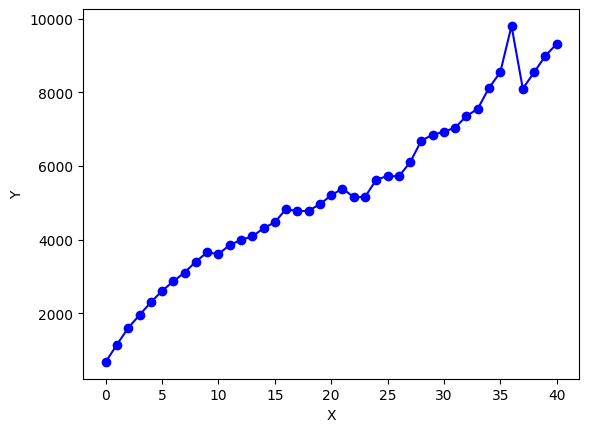

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_content = {'X':[], 'Y':[]}
for i in range(41):
  y_pred = bst_updated.predict(np.array(i).reshape(-1,1)) #업데이트 하지 않은 모델로 하려면 bst_updated -> model
  df_content['X'].append(i)
  df_content['Y'].append(y_pred)
  print(f'{i} >>',y_pred/60)
df=pd.DataFrame(df_content)
plt.plot(df['X'],df['Y'],color='blue',linestyle='-',marker='o')

plt.xlabel('X') #x 라벨
plt.ylabel('Y') #y 라벨

#그래프 출력
plt.show()